## SSLIP in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import defdap.hrdic as hrdic
import defdap.ebsd as ebsd

# try tk, qt, osx (if using mac) or notebook for interactive plots. If none work, use inline
%matplotlib widget

from defdap.sslip import *

## Test Ni dataset (Michael Atkinson)

In [ ]:
dic_filepath = "../tests/data/testDataDIC.txt"
dicMap = hrdic.Map(dic_filepath)
dicMap.set_scale(20/2048)
dicMap.set_crop(left=0, right=0, top=0, bottom=0)
ebsd_map = ebsd.Map("../tests/data/testDataEBSD.cpr")
ebsd_map.data.generate('grain_boundaries', misori_tol=8)
ebsd_map.data.generate('grains', min_grain_size=10)
ebsd_map.calc_average_grain_schmid_factors(load_vector=np.array([1,0,0]), slip_systems=None)
dicMap.frame.homog_points = [(36, 72), (279, 27), (162, 174), (60, 157)]
ebsd_map.frame.homog_points = [(68, 95), (308, 45), (191, 187), (89, 174)]
dicMap.link_ebsd_map(ebsd_map, transform_type="affine")

Loaded DaVis 8.4.0 data (dimensions: 300 x 200 pixels, sub-window size: 12 x 12 pixels)
Loaded EBSD data (dimensions: 359 x 243 pixels, step size: 0.12 um)
Finished building quaternion array (0:00:00) 
Finished finding grain boundaries (0:00:00) 
Finished finding grains (0:00:01) 
Finished calculating grain average Schmid factors (0:00:00) 
Finished finding grains (0:00:00) 


In [ ]:
##Choose grain
dic_grain = dicMap[7]

## Plot grain

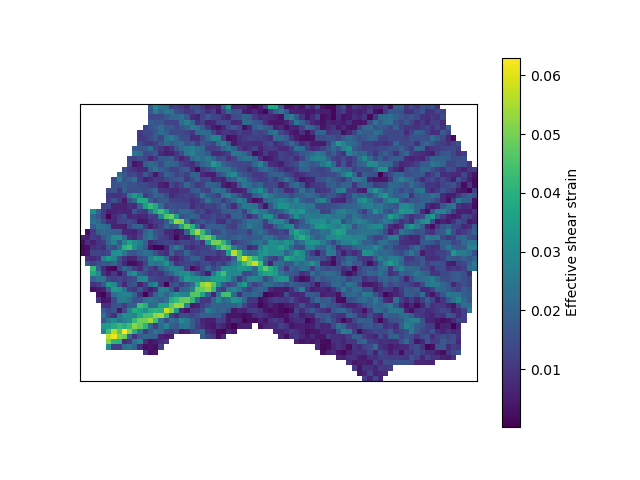

In [3]:
dic_grain.plot_map('max_shear')

## Using CVXPY to solve a second order cone optimisation problem - including parameters

In [7]:
slip_amplitudes = dic_grain.run_sslip_grain(threshold = 0.01)

100%|██████████| 3260/3260 [00:01<00:00, 2259.19it/s]

SSLIP complete. Slip system amplitudes:

Slip System	Amplitude	(Percentage)
(111), [011̅] 	0.00    	(0.0 %)
(111), [1̅01] 	0.00    	(0.0 %)
(111), [11̅0] 	0.00    	(0.0 %)
(111̅), [011] 	1.91    	(1.9 %)
(111̅), [1̅01̅] 	2.34    	(2.3 %)
(111̅), [11̅0] 	4.41    	(4.4 %)
(1̅11), [011̅] 	44.97    	(44.7 %)
(1̅11), [101] 	2.40    	(2.4 %)
(1̅11), [1̅1̅0] 	3.82    	(3.8 %)
(11̅1), [01̅1̅] 	0.89    	(0.9 %)
(11̅1), [1̅01] 	36.01    	(35.8 %)
(11̅1), [110] 	3.95    	(3.9 %)


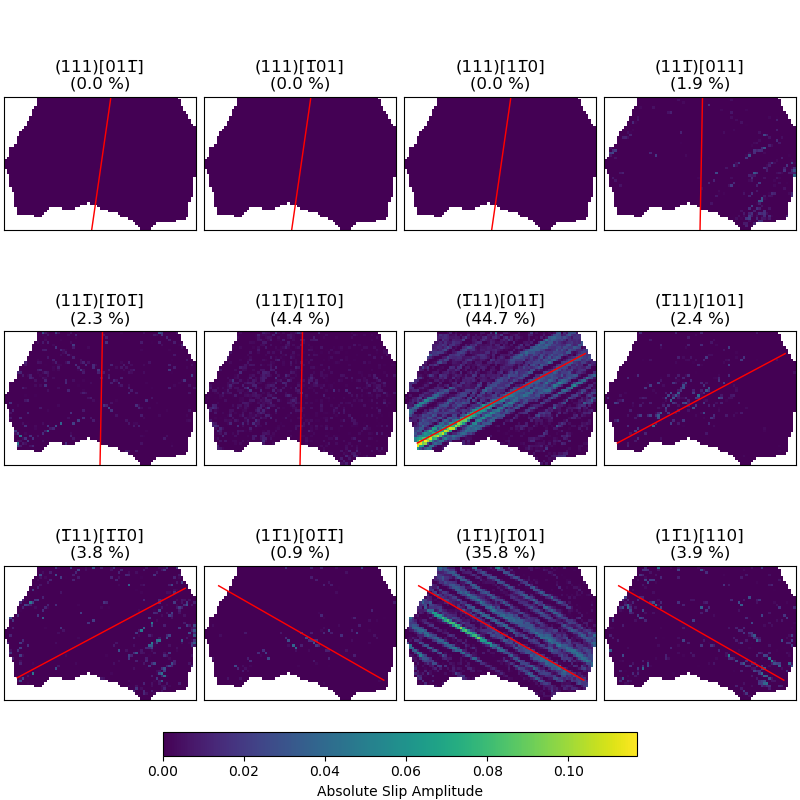

In [8]:
plot_sslip_all(dic_grain, slip_amplitudes, absolute_amplitudes=True)